# Laboratory Assignment 8 — High-Performance Big Data Analytics Using R

## NYC TLC Yellow Taxi — Kaggle version

Dataset supplied:
`https://www.kaggle.com/datasets/marcbrandner/tlc-trip-record-data-yellow-taxi`

### Why this version is different

The earlier notebook failed during file discovery because the Kaggle dataset may be packaged differently from the assumptions in the original reader.

This notebook therefore:

- searches the complete `/kaggle/input` tree
- supports `.csv`, `.csv.gz`, `.zip`, and `.parquet`
- inspects the real headers before choosing a file
- supports common TLC field-name variants
- never calls `normalize_trip_columns()`
- always creates an object named `trips`
- reads only a limited number of rows for the lab
- does not require `PULocationID` / `DOLocationID` when the supplied data is an older coordinate-based TLC file
- completes the Assignment 8 analysis, functional/vectorized comparison, sequential/parallel processing, benchmarking, visualizations, observations, and conclusion

In [1]:
# CELL 1 — Packages

required_packages <- c(
  "data.table",
  "ggplot2",
  "lubridate",
  "purrr",
  "foreach",
  "doParallel",
  "microbenchmark"
)

for (pkg in required_packages) {
  if (!requireNamespace(pkg, quietly = TRUE)) {
    install.packages(
      pkg,
      repos = "https://cloud.r-project.org",
      quiet = TRUE
    )
  }
}

suppressPackageStartupMessages({
  library(data.table)
  library(ggplot2)
  library(lubridate)
  library(purrr)
  library(foreach)
  library(doParallel)
  library(microbenchmark)
})

set.seed(42)

options(
  stringsAsFactors = FALSE,
  datatable.print.nrows = 20
)

cat("Packages loaded successfully.\\n")

Packages loaded successfully.\n

In [2]:
# CELL 2 — Configuration

KAGGLE_INPUT <- "/kaggle/input"

# These values keep the notebook safe for Kaggle RAM.
ROWS_PER_FILE <- 250000L
TOTAL_ROW_LIMIT <- 500000L
BENCHMARK_ROWS <- 100000L

# Read one or more files if available.
# Increase only after the notebook is working.
MAX_TRIP_FILES <- 2L

cat(
  "Rows per file:",
  format(ROWS_PER_FILE, big.mark = ","),
  "\\n"
)

cat(
  "Maximum rows in memory:",
  format(TOTAL_ROW_LIMIT, big.mark = ","),
  "\\n"
)

Rows per file: 250,000 \nMaximum rows in memory: 500,000 \n

In [3]:
# CELL 3 — Find all possible Kaggle data files

all_files <- list.files(
  KAGGLE_INPUT,
  recursive = TRUE,
  full.names = TRUE,
  include.dirs = FALSE
)

# Candidate data formats.
candidate_files <- all_files[
  grepl(
    "\\.(csv|csv\\.gz|zip|parquet)$",
    all_files,
    ignore.case = TRUE
  )
]

if (length(candidate_files) == 0) {
  stop(
    paste0(
      "No CSV/CSV.GZ/ZIP/Parquet file was found under /kaggle/input.\\n",
      "Please add the Kaggle dataset to the notebook."
    )
  )
}

# Prefer files that look like Yellow Taxi/TLC trip data.
name_score <- function(path) {
  nm <- tolower(basename(path))

  score <- 0L

  if (grepl("yellow", nm)) score <- score + 100L
  if (grepl("taxi", nm))   score <- score + 50L
  if (grepl("trip", nm))   score <- score + 25L

  # Penalize obvious lookup/reference files.
  if (grepl("lookup|zone", nm)) score <- score - 100L

  score
}

file_table <- data.table(
  file = candidate_files,
  filename = basename(candidate_files),
  size_mb = round(
    file.info(candidate_files)$size / 1024^2,
    2
  )
)

file_table[
  ,
  score := vapply(
    file,
    name_score,
    integer(1)
  )
]

setorder(
  file_table,
  -score,
  -size_mb
)

cat("Files found under /kaggle/input:\\n")
print(file_table)

# Candidates shown to the reader in descending relevance.
candidate_files <- file_table$filename
candidate_paths <- file_table$file

Files found under /kaggle/input:\n                                                                                                     file
                                                                                                   <char>
  1: /kaggle/input/datasets/marcbrandner/tlc-trip-record-data-yellow-taxi/yellow_tripdata_2010-05.parquet
  2: /kaggle/input/datasets/marcbrandner/tlc-trip-record-data-yellow-taxi/yellow_tripdata_2010-04.parquet
  3: /kaggle/input/datasets/marcbrandner/tlc-trip-record-data-yellow-taxi/yellow_tripdata_2009-10.parquet
  4: /kaggle/input/datasets/marcbrandner/tlc-trip-record-data-yellow-taxi/yellow_tripdata_2010-06.parquet
  5: /kaggle/input/datasets/marcbrandner/tlc-trip-record-data-yellow-taxi/yellow_tripdata_2010-01.parquet
 ---                                                                                                     
163: /kaggle/input/datasets/marcbrandner/tlc-trip-record-data-yellow-taxi/yellow_tripdata_2020-07.parquet
164: /kaggle

In [4]:
# CELL 4 — Functions to inspect compressed/uncompressed files

# Safely quote paths for shell commands.
shq <- function(x) {
  shQuote(x)
}

# Return one header line from a data file without loading the data.

read_header_names <- function(path) {

  nm <- tolower(basename(path))
  ext <- tolower(tools::file_ext(path))

  # ----------------------------------------------------------
  # Plain CSV
  # ----------------------------------------------------------
  if (ext == "csv") {

    z <- tryCatch(
      fread(
        path,
        nrows = 0L,
        showProgress = FALSE
      ),
      error = function(e) NULL
    )

    if (!is.null(z)) {
      return(names(z))
    }
  }

  # ----------------------------------------------------------
  # GZIP CSV
  # ----------------------------------------------------------
  if (grepl("\\.csv\\.gz$", nm, ignore.case = TRUE)) {

    cmd <- paste(
      "gzip -cd",
      shq(path),
      "| head -n 1"
    )

    z <- tryCatch(
      fread(
        cmd = cmd,
        nrows = 0L,
        showProgress = FALSE
      ),
      error = function(e) NULL
    )

    if (!is.null(z)) {
      return(names(z))
    }
  }

  # ----------------------------------------------------------
  # ZIP containing a CSV
  # ----------------------------------------------------------
  if (ext == "zip") {

    members <- tryCatch(
      system2(
        "unzip",
        c(
          "-Z1",
          path
        ),
        stdout = TRUE
      ),
      error = function(e) character(0)
    )

    csv_members <- members[
      grepl(
        "\\.(csv|csv\\.gz)$",
        members,
        ignore.case = TRUE
      )
    ]

    if (length(csv_members) > 0) {

      member <- csv_members[1]

      cmd <- paste(
        "unzip -p",
        shq(path),
        shq(member),
        "| head -n 1"
      )

      z <- tryCatch(
        fread(
          cmd = cmd,
          nrows = 0L,
          showProgress = FALSE
        ),
        error = function(e) NULL
      )

      if (!is.null(z)) {
        return(names(z))
      }
    }
  }

  # ----------------------------------------------------------
  # Parquet
  # ----------------------------------------------------------
  if (ext == "parquet") {

    if (requireNamespace("arrow", quietly = TRUE)) {

      z <- tryCatch(
        arrow::read_schema(path)$names,
        error = function(e) NULL
      )

      if (!is.null(z)) {
        return(z)
      }
    }
  }

  character(0)
}

header_table <- rbindlist(
  lapply(
    candidate_paths,
    function(path) {
      cols <- read_header_names(path)

      data.table(
        file = path,
        filename = basename(path),
        n_columns = length(cols),
        columns = paste(cols, collapse = " | ")
      )
    }
  ),
  fill = TRUE
)

cat("Detected file headers:\\n")
print(
  header_table[
    ,
    .(
      filename,
      n_columns,
      columns
    )
  ],
  nrows = 100L
)

Detected file headers:\n                            filename n_columns
                              <char>     <int>
  1: yellow_tripdata_2010-05.parquet         0
  2: yellow_tripdata_2010-04.parquet         0
  3: yellow_tripdata_2009-10.parquet         0
  4: yellow_tripdata_2010-06.parquet         0
  5: yellow_tripdata_2010-01.parquet         0
 ---                                          
163: yellow_tripdata_2020-07.parquet         0
164: yellow_tripdata_2020-06.parquet         0
165: yellow_tripdata_2020-05.parquet         0
166: yellow_tripdata_2020-04.parquet         0
167:            taxi_zone_lookup.csv         4
                                        columns
                                         <char>
  1:                                           
  2:                                           
  3:                                           
  4:                                           
  5:                                           
 ---                         

In [5]:
# CELL 5 — Flexible TLC column aliases

clean_name <- function(x) {
  x <- tolower(trimws(x))
  gsub("[^a-z0-9]", "", x)
}

# The supplied Kaggle data can contain different generations
# of TLC column names.

aliases <- list(

  pickup_datetime = c(
    "tpep_pickup_datetime",
    "lpep_pickup_datetime",
    "pickup_datetime",
    "pick_up_datetime",
    "pickup_date_time"
  ),

  dropoff_datetime = c(
    "tpep_dropoff_datetime",
    "lpep_dropoff_datetime",
    "dropoff_datetime",
    "drop_off_datetime",
    "dropoff_date_time"
  ),

  pu_location_id = c(
    "PULocationID",
    "pickup_location_id",
    "pu_location_id",
    "pickupzoneid"
  ),

  do_location_id = c(
    "DOLocationID",
    "dropoff_location_id",
    "do_location_id",
    "dropoffzoneid"
  ),

  pickup_longitude = c(
    "pickup_longitude",
    "pickup_long",
    "pu_longitude",
    "start_lon",
    "pickup_lon"
  ),

  pickup_latitude = c(
    "pickup_latitude",
    "pickup_lat",
    "pu_latitude",
    "start_lat",
    "pickup_lat"
  ),

  dropoff_longitude = c(
    "dropoff_longitude",
    "dropoff_long",
    "do_longitude",
    "end_lon",
    "dropoff_lon"
  ),

  dropoff_latitude = c(
    "dropoff_latitude",
    "dropoff_lat",
    "do_latitude",
    "end_lat",
    "dropoff_lat"
  ),

  passenger_count = c(
    "passenger_count",
    "passengers",
    "passengercount"
  ),

  trip_distance = c(
    "trip_distance",
    "distance",
    "tripdistance"
  ),

  payment_type = c(
    "payment_type",
    "paymenttype",
    "payment_method",
    "paymentmethod"
  ),

  fare_amount = c(
    "fare_amount",
    "fare",
    "fareamount"
  ),

  tip_amount = c(
    "tip_amount",
    "tip",
    "tipamount"
  ),

  tolls_amount = c(
    "tolls_amount",
    "toll_amount",
    "tolls",
    "tollsamount"
  ),

  total_amount = c(
    "total_amount",
    "total_fare",
    "total",
    "totalamount"
  )
)

resolve_schema <- function(actual_names) {

  actual_clean <- clean_name(actual_names)

  result <- list()

  for (target in names(aliases)) {

    options_clean <- clean_name(
      aliases[[target]]
    )

    idx <- match(
      options_clean,
      actual_clean,
      nomatch = 0L
    )

    idx <- idx[idx > 0L]

    if (length(idx) > 0L) {

      result[[target]] <-
        actual_names[idx[1L]]
    }
  }

  result
}

In [6]:
# CELL 6 — Select a REAL compatible trip file

# Do not make LocationID mandatory.
# Coordinates are supported for older TLC records.

required_columns <- c(
  "pickup_datetime",
  "dropoff_datetime",
  "trip_distance",
  "fare_amount",
  "total_amount"
)

compatibility <- lapply(
  seq_len(nrow(header_table)),
  function(i) {

    cols <- strsplit(
      header_table$columns[i],
      " \\| ",
      fixed = FALSE
    )[[1]]

    resolved <- resolve_schema(cols)

    missing <- setdiff(
      required_columns,
      names(resolved)
    )

    data.table(
      file = header_table$file[i],
      filename = header_table$filename[i],
      compatible = length(missing) == 0L,
      missing = paste(
        missing,
        collapse = ", "
      ),
      has_location_ids =
        "pu_location_id" %in% names(resolved) &&
        "do_location_id" %in% names(resolved),
      has_coordinates = all(
        c(
          "pickup_longitude",
          "pickup_latitude",
          "dropoff_longitude",
          "dropoff_latitude"
        ) %in% names(resolved)
      )
    )
  }
)

compatibility <- rbindlist(
  compatibility,
  fill = TRUE
)

cat("Compatibility check:\\n")
print(compatibility)

compatible_files <- compatibility[
  compatible == TRUE,
  file
]

# FALLBACK:
# If header detection cannot inspect a compressed container,
# choose the most likely Yellow Taxi/TLC file and inspect its
# actual first data rows during loading.

if (length(compatible_files) == 0L) {

  likely <- file_table[
    score == max(score),
    file
  ]

  if (length(likely) == 0L) {
    stop(
      "No likely TLC trip file could be identified."
    )
  }

  compatible_files <- likely

  cat(
    "\\nHeader pre-check was inconclusive.\\n",
    "Using highest-scoring TLC candidate:",
    basename(compatible_files[1]),
    "\\n"
  )
}

trip_files <- head(
  compatible_files,
  MAX_TRIP_FILES
)

cat(
  "\\nSelected trip file(s):\\n"
)

print(trip_files)

Compatibility check:\n                                                                                                     file
                                                                                                   <char>
  1: /kaggle/input/datasets/marcbrandner/tlc-trip-record-data-yellow-taxi/yellow_tripdata_2010-05.parquet
  2: /kaggle/input/datasets/marcbrandner/tlc-trip-record-data-yellow-taxi/yellow_tripdata_2010-04.parquet
  3: /kaggle/input/datasets/marcbrandner/tlc-trip-record-data-yellow-taxi/yellow_tripdata_2009-10.parquet
  4: /kaggle/input/datasets/marcbrandner/tlc-trip-record-data-yellow-taxi/yellow_tripdata_2010-06.parquet
  5: /kaggle/input/datasets/marcbrandner/tlc-trip-record-data-yellow-taxi/yellow_tripdata_2010-01.parquet
 ---                                                                                                     
163: /kaggle/input/datasets/marcbrandner/tlc-trip-record-data-yellow-taxi/yellow_tripdata_2020-07.parquet
164: /kaggle/input/datas

In [7]:
# CELL 7 — Read sample from CSV / CSV.GZ / ZIP / Parquet

read_raw_sample <- function(path, nrows = ROWS_PER_FILE) {

  nm <- tolower(basename(path))
  ext <- tolower(tools::file_ext(path))

  # Plain CSV
  if (ext == "csv") {

    return(
      fread(
        path,
        nrows = nrows,
        showProgress = TRUE
      )
    )
  }

  # CSV.GZ
  if (grepl("\\.csv\\.gz$", nm, ignore.case = TRUE)) {

    cmd <- paste(
      "gzip -cd",
      shq(path)
    )

    return(
      fread(
        cmd = cmd,
        nrows = nrows,
        showProgress = TRUE
      )
    )
  }

  # ZIP containing CSV
  if (ext == "zip") {

    members <- system2(
      "unzip",
      c("-Z1", path),
      stdout = TRUE
    )

    csv_members <- members[
      grepl(
        "\\.(csv|csv\\.gz)$",
        members,
        ignore.case = TRUE
      )
    ]

    if (length(csv_members) == 0L) {
      stop(
        "ZIP file does not contain a CSV/CSV.GZ trip file: ",
        path
      )
    }

    # Prefer a member with yellow/taxi/trip in its name.
    member_scores <- vapply(
      csv_members,
      function(x) {
        name_score(x)
      },
      integer(1)
    )

    member <- csv_members[
      which.max(member_scores)
    ]

    cat(
      "Reading ZIP member:",
      member,
      "\\n"
    )

    # For a CSV.GZ inside ZIP, first stream through gzip -cd.
    if (grepl(
      "\\.csv\\.gz$",
      member,
      ignore.case = TRUE
    )) {

      cmd <- paste(
        "unzip -p",
        shq(path),
        shq(member),
        "| gzip -cd"
      )

    } else {

      cmd <- paste(
        "unzip -p",
        shq(path),
        shq(member)
      )
    }

    return(
      fread(
        cmd = cmd,
        nrows = nrows,
        showProgress = TRUE
      )
    )
  }

  # Parquet
  if (ext == "parquet") {

    if (!requireNamespace("arrow", quietly = TRUE)) {
      install.packages(
        "arrow",
        repos = "https://cloud.r-project.org",
        quiet = TRUE
      )
    }

    ds <- arrow::open_dataset(
      path,
      format = "parquet"
    )

    return(
      as.data.table(
        ds |>
          dplyr::slice_head(n = as.integer(nrows)) |>
          dplyr::collect()
      )
    )
  }

  stop(
    "Unsupported file type: ",
    path
  )
}

# Read one or more selected files.
raw_list <- lapply(
  trip_files,
  function(path) {

    cat(
      "\\n==================================================\\n",
      "Reading: ",
      basename(path),
      "\\n",
      "==================================================\\n",
      sep = ""
    )

    x <- read_raw_sample(
      path,
      ROWS_PER_FILE
    )

    cat(
      "Rows read:",
      format(nrow(x), big.mark = ","),
      "\\n"
    )

    cat(
      "Columns detected:",
      ncol(x),
      "\\n"
    )

    cat(
      "Column names:\\n"
    )

    print(names(x))

    x
  }
)

# Always create `trips`.
trips <- rbindlist(
  raw_list,
  use.names = TRUE,
  fill = TRUE
)

rm(raw_list)
gc(verbose = FALSE)

# Apply final RAM protection.
if (nrow(trips) > TOTAL_ROW_LIMIT) {

  trips <- trips[
    seq_len(TOTAL_ROW_LIMIT)
  ]
}

cat(
  "\\n==================================================\\n",
  "SUCCESS — object `trips` has been created\\n",
  "Rows: ", format(nrow(trips), big.mark = ","), "\\n",
  "Columns: ", ncol(trips), "\\n",
  "==================================================\\n",
  sep = ""
)

print(head(trips, 5))

\n==================================================\nReading: yellow_tripdata_2010-05.parquet\n==================================================\nRows read: 250,000 \nColumns detected: 18 \nColumn names:\n [1] "vendor_id"          "pickup_datetime"    "dropoff_datetime"  
 [4] "passenger_count"    "trip_distance"      "pickup_longitude"  
 [7] "pickup_latitude"    "rate_code"          "store_and_fwd_flag"
[10] "dropoff_longitude"  "dropoff_latitude"   "payment_type"      
[13] "fare_amount"        "surcharge"          "mta_tax"           
[16] "tip_amount"         "tolls_amount"       "total_amount"      
\n==================================================\nReading: yellow_tripdata_2010-04.parquet\n==================================================\nRows read: 250,000 \nColumns detected: 18 \nColumn names:\n [1] "vendor_id"          "pickup_datetime"    "dropoff_datetime"  
 [4] "passenger_count"    "trip_distance"      "pickup_longitude"  
 [7] "pickup_latitude"    "rate_code"     

,used,(Mb),gc trigger,(Mb),max used,(Mb)
Ncells,2017166,107.8,3414607,182.4,2317741,123.8
Vcells,13752852,105.0,24612458,187.8,22540385,172.0


\n==================================================\nSUCCESS — object `trips` has been created\nRows: 500,000\nColumns: 18\n==================================================\n   vendor_id     pickup_datetime    dropoff_datetime passenger_count
      <char>              <char>              <char>           <int>
1:       CMT 2010-05-28 21:09:20 2010-05-28 21:30:50               2
2:       CMT 2010-05-28 15:58:09 2010-05-28 16:01:31               1
3:       CMT 2010-05-28 10:42:44 2010-05-28 10:46:14               1
4:       CMT 2010-05-27 23:14:35 2010-05-27 23:22:23               1
5:       CMT 2010-05-28 00:10:10 2010-05-28 00:12:18               1
   trip_distance pickup_longitude pickup_latitude rate_code store_and_fwd_flag
           <num>            <num>           <num>    <char>             <char>
1:           4.6        -74.00168        40.72134         1                  0
2:           0.7        -73.95565        40.77658         1                  0
3:           0.4        

In [8]:
# CELL 8 — Normalize AFTER reading the actual columns

stopifnot(exists("trips"))

actual_columns <- names(trips)
resolved <- resolve_schema(actual_columns)

cat("Resolved TLC schema:\\n")
print(resolved)

missing_required <- setdiff(
  required_columns,
  names(resolved)
)

if (length(missing_required) > 0L) {

  stop(
    paste0(
      "The selected Kaggle file was read successfully, but the ",
      "following required analytical fields could not be mapped:\\n",
      paste(missing_required, collapse = ", "),
      "\\n\\nActual columns in the Kaggle file are:\\n",
      paste(actual_columns, collapse = ", "),
      "\\n\\nThis is now a REAL schema message, not a file-discovery failure."
    )
  )
}

# Rename only fields that exist.
source_names <- unname(unlist(resolved))

target_names <- names(resolved)

rename_idx <- match(
  source_names,
  names(trips)
)

setnames(
  trips,
  old = source_names[!is.na(rename_idx)],
  new = target_names[!is.na(rename_idx)]
)

# Add optional columns when absent.
optional_numeric <- c(
  "tip_amount",
  "tolls_amount",
  "passenger_count",
  "payment_type",
  "pickup_longitude",
  "pickup_latitude",
  "dropoff_longitude",
  "dropoff_latitude"
)

for (nm in optional_numeric) {

  if (!nm %in% names(trips)) {

    trips[
      ,
      (nm) := NA_real_
    ]
  }
}

# Location IDs:
# - use actual IDs when present
# - otherwise build location labels from coordinates

if ("pu_location_id" %in% names(trips)) {

  trips[
    ,
    pu_location_id := as.character(pu_location_id)
  ]

} else {

  trips[
    ,
    pu_location_id := paste0(
      "PU_",
      round(
        suppressWarnings(
          as.numeric(pickup_longitude)
        ),
        3
      ),
      "_",
      round(
        suppressWarnings(
          as.numeric(pickup_latitude)
        ),
        3
      )
    )
  ]
}

if ("do_location_id" %in% names(trips)) {

  trips[
    ,
    do_location_id := as.character(do_location_id)
  ]

} else {

  trips[
    ,
    do_location_id := paste0(
      "DO_",
      round(
        suppressWarnings(
          as.numeric(dropoff_longitude)
        ),
        3
      ),
      "_",
      round(
        suppressWarnings(
          as.numeric(dropoff_latitude)
        ),
        3
      )
    )
  ]
}

cat(
  "\\nNormalization complete.\\n"
)

Resolved TLC schema:\n$pickup_datetime
[1] "pickup_datetime"

$dropoff_datetime
[1] "dropoff_datetime"

$pickup_longitude
[1] "pickup_longitude"

$pickup_latitude
[1] "pickup_latitude"

$dropoff_longitude
[1] "dropoff_longitude"

$dropoff_latitude
[1] "dropoff_latitude"

$passenger_count
[1] "passenger_count"

$trip_distance
[1] "trip_distance"

$payment_type
[1] "payment_type"

$fare_amount
[1] "fare_amount"

$tip_amount
[1] "tip_amount"

$tolls_amount
[1] "tolls_amount"

$total_amount
[1] "total_amount"

\nNormalization complete.\n

In [9]:
# CELL 9 — Inspect the successfully loaded data

stopifnot(
  exists("trips")
)

cat("Dimensions:\\n")
print(dim(trips))

cat("\\nColumn names:\\n")
print(names(trips))

cat("\\nData types:\\n")
print(sapply(trips, class))

cat("\\nMissing values:\\n")
print(
  sort(
    sapply(
      trips,
      function(x) sum(is.na(x))
    ),
    decreasing = TRUE
  )
)

cat(
  "\\nDuplicate rows:",
  sum(duplicated(trips)),
  "\\n"
)

cat(
  "\\nObject memory:",
  format(
    object.size(trips),
    units = "auto"
  ),
  "\\n"
)

Dimensions:\n[1] 500000     20
\nColumn names:\n [1] "vendor_id"          "pickup_datetime"    "dropoff_datetime"  
 [4] "passenger_count"    "trip_distance"      "pickup_longitude"  
 [7] "pickup_latitude"    "rate_code"          "store_and_fwd_flag"
[10] "dropoff_longitude"  "dropoff_latitude"   "payment_type"      
[13] "fare_amount"        "surcharge"          "mta_tax"           
[16] "tip_amount"         "tolls_amount"       "total_amount"      
[19] "pu_location_id"     "do_location_id"    
\nData types:\n         vendor_id    pickup_datetime   dropoff_datetime    passenger_count 
       "character"        "character"        "character"          "integer" 
     trip_distance   pickup_longitude    pickup_latitude          rate_code 
         "numeric"          "numeric"          "numeric"        "character" 
store_and_fwd_flag  dropoff_longitude   dropoff_latitude       payment_type 
       "character"          "numeric"          "numeric"        "character" 
       fare_amount  

In [10]:
# CELL 10 — Data cleaning and feature engineering

stopifnot(
  exists("trips")
)

rows_before <- nrow(trips)

# Date/time parsing
parse_tlc_datetime <- function(x) {

  if (inherits(x, "POSIXct")) {
    return(x)
  }

  suppressWarnings(
    parse_date_time(
      as.character(x),
      orders = c(
        "ymd HMS",
        "ymd HM",
        "mdy HMS",
        "mdy HM"
      ),
      tz = "America/New_York",
      quiet = TRUE
    )
  )
}

trips[
  ,
  pickup_datetime := parse_tlc_datetime(
    pickup_datetime
  )
]

trips[
  ,
  dropoff_datetime := parse_tlc_datetime(
    dropoff_datetime
  )
]

# Numeric conversion
numeric_columns <- c(
  "passenger_count",
  "trip_distance",
  "payment_type",
  "fare_amount",
  "tip_amount",
  "tolls_amount",
  "total_amount",
  "pickup_longitude",
  "pickup_latitude",
  "dropoff_longitude",
  "dropoff_latitude"
)

for (nm in numeric_columns) {

  if (nm %in% names(trips)) {

    set(
      trips,
      j = nm,
      value = suppressWarnings(
        as.numeric(trips[[nm]])
      )
    )
  }
}

# Remove exact duplicate records
trips <- unique(trips)

# Trip duration
trips[
  ,
  trip_minutes := as.numeric(
    difftime(
      dropoff_datetime,
      pickup_datetime,
      units = "mins"
    )
  )
]

# Validity filters
trips_clean <- trips[
  !is.na(pickup_datetime) &
    !is.na(dropoff_datetime) &
    !is.na(trip_distance) &
    !is.na(fare_amount) &
    !is.na(total_amount) &

    trip_minutes > 0 &
    trip_minutes <= 1440 &

    trip_distance > 0 &
    trip_distance <= 200 &

    fare_amount >= 0 &
    total_amount >= 0 &

    (
      is.na(passenger_count) |
        (
          passenger_count >= 0 &
            passenger_count <= 10
        )
    )
]

# Temporal features
trips_clean[
  ,
  hour := hour(pickup_datetime)
]

trips_clean[
  ,
  day := day(pickup_datetime)
]

trips_clean[
  ,
  weekday := wday(
    pickup_datetime,
    label = TRUE,
    abbr = FALSE,
    week_start = 1
  )
]

trips_clean[
  ,
  month := month(pickup_datetime)
]

trips_clean[
  ,
  year_month := format(
    pickup_datetime,
    "%Y-%m"
  )
]

# Payment labels
payment_labels <- c(
  `1` = "Credit card",
  `2` = "Cash",
  `3` = "No charge",
  `4` = "Dispute",
  `5` = "Unknown",
  `6` = "Voided"
)

trips_clean[
  ,
  payment_label := unname(
    payment_labels[
      as.character(payment_type)
    ]
  )
]

trips_clean[
  is.na(payment_label),
  payment_label := "Unknown/Other"
]

# Route
trips_clean[
  ,
  route := paste(
    pu_location_id,
    "->",
    do_location_id
  )
]

rows_after <- nrow(trips_clean)

cat(
  "Rows before cleaning:",
  format(rows_before, big.mark = ","),
  "\\n"
)

cat(
  "Rows after cleaning:",
  format(rows_after, big.mark = ","),
  "\\n"
)

cat(
  "Rows removed:",
  format(rows_before - rows_after, big.mark = ","),
  "\\n"
)

cat(
  "Retention:",
  round(
    rows_after / rows_before * 100,
    2
  ),
  "%\\n"
)

Rows before cleaning: 500,000 \nRows after cleaning: 496,660 \nRows removed: 3,340 \nRetention: 99.33 %\n

In [11]:
# CELL 11 — Taxi Zone Lookup when real LocationIDs exist

stopifnot(
  exists("trips_clean")
)

trips_clean[
  ,
  pickup_zone := pu_location_id
]

trips_clean[
  ,
  dropoff_zone := do_location_id
]

trips_clean[
  ,
  pickup_borough := "Unknown"
]

trips_clean[
  ,
  dropoff_borough := "Unknown"
]

# Check whether IDs appear to be real TLC numeric IDs.
real_ids <- suppressWarnings(
  mean(
    grepl(
      "^[0-9]+$",
      head(
        trips_clean$pu_location_id,
        1000
      )
    ),
    na.rm = TRUE
  )
) > 0.5

if (real_ids) {

  # Look for a lookup file attached to the Kaggle dataset.
  zone_candidates <- all_files[
    grepl(
      "taxi.*zone|zone.*lookup",
      basename(all_files),
      ignore.case = TRUE
    ) &
      grepl(
        "\\.(csv|csv\\.gz)$",
        basename(all_files),
        ignore.case = TRUE
      )
  ]

  if (length(zone_candidates) > 0) {

    zone_file <- zone_candidates[1]

    zones <- tryCatch(
      fread(
        zone_file,
        showProgress = FALSE
      ),
      error = function(e) NULL
    )

    if (!is.null(zones)) {

      names(zones) <- clean_name(names(zones))

      if ("locationid" %in% names(zones)) {

        if (!"zone" %in% names(zones)) {
          zones[
            ,
            zone := paste0(
              "Zone ",
              locationid
            )
          ]
        }

        if (!"borough" %in% names(zones)) {
          zones[
            ,
            borough := "Unknown"
          ]
        }

        zones[
          ,
          locationid :=
            as.character(locationid)
        ]

        pickup_map <- zones[
          ,
          .(
            pu_location_id = locationid,
            pickup_zone = as.character(zone),
            pickup_borough = as.character(borough)
          )
        ]

        dropoff_map <- zones[
          ,
          .(
            do_location_id = locationid,
            dropoff_zone = as.character(zone),
            dropoff_borough = as.character(borough)
          )
        ]

        trips_clean[
          pickup_map,
          on = "pu_location_id",
          `:=`(
            pickup_zone = i.pickup_zone,
            pickup_borough = i.pickup_borough
          )
        ]

        trips_clean[
          dropoff_map,
          on = "do_location_id",
          `:=`(
            dropoff_zone = i.dropoff_zone,
            dropoff_borough = i.dropoff_borough
          )
        ]

        cat(
          "Taxi Zone Lookup joined successfully.\\n"
        )
      }
    }
  } else {

    cat(
      "No taxi zone lookup file was attached.\\n",
      "LocationID values are retained for route analysis.\\n"
    )
  }

} else {

  cat(
    "Older/coordinate-based TLC file detected.\\n",
    "Zone lookup join skipped.\\n"
  )
}

Older/coordinate-based TLC file detected.\n Zone lookup join skipped.\n

# 2. Transportation analytics

The following cells implement the required taxi-demand, fare, revenue, route, payment, and trip-distance analyses using `data.table`.

In [12]:
# CELL 12 — Trips by hour

hourly_demand <- trips_clean[
  ,
  .(
    trips = .N,
    average_fare = mean(
      fare_amount,
      na.rm = TRUE
    ),
    total_revenue = sum(
      total_amount,
      na.rm = TRUE
    )
  ),
  by = hour
][order(hour)]

print(hourly_demand)

     hour trips average_fare total_revenue
    <int> <int>        <num>         <num>
 1:     0 19554    10.312928     238278.69
 2:     1 14410    10.206661     173446.59
 3:     2 10991    10.305764     132983.81
 4:     3  7766    10.644450      96962.70
 5:     4  5537    11.732617      76201.97
---                                       
20:    19 31393     9.288998     356880.77
21:    20 29425     9.555536     336960.61
22:    21 28227     9.759105     329264.19
23:    22 27155    10.026640     324313.06
24:    23 24660    10.328453     301916.67


In [13]:
# CELL 13 — Trips by weekday

weekday_demand <- trips_clean[
  ,
  .(
    trips = .N,
    average_fare = mean(
      fare_amount,
      na.rm = TRUE
    ),
    total_revenue = sum(
      total_amount,
      na.rm = TRUE
    )
  ),
  by = weekday
][order(weekday)]

print(weekday_demand)

     weekday trips average_fare total_revenue
       <ord> <int>        <num>         <num>
1:    Monday 64728     9.911295      760676.4
2:   Tuesday 64937     9.746638      751277.9
3: Wednesday 68106     9.877133      798113.6
4:  Thursday 77604    10.113271      929368.1
5:    Friday 80030     9.971048      943159.8
6:  Saturday 76550     9.786703      861742.6
7:    Sunday 64705    10.207755      763604.7


In [14]:
# CELL 14 — Monthly taxi demand

monthly_demand <- trips_clean[
  ,
  .(
    trips = .N,
    average_fare = mean(
      fare_amount,
      na.rm = TRUE
    ),
    total_revenue = sum(
      total_amount,
      na.rm = TRUE
    ),
    average_distance = mean(
      trip_distance,
      na.rm = TRUE
    )
  ),
  by = year_month
][order(year_month)]

print(monthly_demand)

   year_month  trips average_fare total_revenue average_distance
       <char>  <int>        <num>         <num>            <num>
1:    2010-04 248360     9.852055       2880695         2.771831
2:    2010-05 248300    10.039346       2927248         2.826493


In [15]:
# CELL 15 — Most frequent routes

top_routes <- trips_clean[
  ,
  .(
    trips = .N,
    total_revenue = sum(
      total_amount,
      na.rm = TRUE
    ),
    average_fare = mean(
      fare_amount,
      na.rm = TRUE
    )
  ),
  by = .(
    pickup_zone,
    dropoff_zone
  )
][
  order(-trips)
][
  1:min(15L, .N)
]

print(top_routes)

          pickup_zone      dropoff_zone trips total_revenue average_fare
               <char>            <char> <int>         <num>        <num>
 1:            PU_0_0            DO_0_0  9844     114170.49     9.901524
 2: PU_-73.137_41.366 DO_-73.137_41.366   568       7191.92    10.740141
 3: PU_-73.937_40.758 DO_-73.937_40.758   114       1373.30    10.400000
 4: PU_-73.938_40.758 DO_-73.938_40.758    61        792.16    11.078689
 5: PU_-73.902_40.764 DO_-73.902_40.764    57        291.30     4.647368
 6: PU_-73.929_40.744 DO_-73.929_40.744    53        610.51     9.792453
 7: PU_-73.951_40.802 DO_-73.951_40.802    51        504.70     8.476471
 8: PU_-73.996_40.761 DO_-73.996_40.761    43        536.79    10.741860
 9: PU_-73.956_40.779 DO_-73.956_40.779    43        592.18    11.825581
10: PU_-74.007_40.735 DO_-74.007_40.735    37        362.87     8.586486
11: PU_-73.876_40.773 DO_-73.876_40.773    31        459.31    12.680645
12:  PU_-73.996_40.76  DO_-73.996_40.76    30      

In [16]:
# CELL 16 — Highest-revenue routes

top_revenue_routes <- trips_clean[
  ,
  .(
    trips = .N,
    total_revenue = sum(
      total_amount,
      na.rm = TRUE
    ),
    average_fare = mean(
      fare_amount,
      na.rm = TRUE
    )
  ),
  by = .(
    pickup_zone,
    dropoff_zone
  )
][
  order(-total_revenue)
][
  1:min(15L, .N)
]

print(top_revenue_routes)

          pickup_zone      dropoff_zone trips total_revenue average_fare
               <char>            <char> <int>         <num>        <num>
 1:            PU_0_0            DO_0_0  9844     114170.49     9.901524
 2: PU_-73.137_41.366 DO_-73.137_41.366   568       7191.92    10.740141
 3: PU_-73.937_40.758 DO_-73.937_40.758   114       1373.30    10.400000
 4: PU_-73.938_40.758 DO_-73.938_40.758    61        792.16    11.078689
 5: PU_-73.929_40.744 DO_-73.929_40.744    53        610.51     9.792453
 6: PU_-73.956_40.779 DO_-73.956_40.779    43        592.18    11.825581
 7: PU_-73.873_40.774 DO_-73.979_40.762    16        551.68    26.625000
 8: PU_-73.996_40.761 DO_-73.996_40.761    43        536.79    10.741860
 9: PU_-73.951_40.802 DO_-73.951_40.802    51        504.70     8.476471
10: PU_-73.979_40.762 DO_-73.873_40.774    14        461.18    25.814286
11: PU_-73.876_40.773 DO_-73.876_40.773    31        459.31    12.680645
12: PU_-73.873_40.774 DO_-73.973_40.756    13      

In [17]:
# CELL 17 — Distance and fare relationship

distance_fare_summary <- trips_clean[
  ,
  .(
    correlation = cor(
      trip_distance,
      fare_amount,
      use = "complete.obs"
    ),
    average_distance = mean(
      trip_distance,
      na.rm = TRUE
    ),
    average_fare = mean(
      fare_amount,
      na.rm = TRUE
    )
  )
]

print(distance_fare_summary)

   correlation average_distance average_fare
         <num>            <num>        <num>
1:   0.9510002         2.799159     9.945689


In [18]:
# CELL 18 — Payment preferences

payment_summary <- trips_clean[
  ,
  .(
    trips = .N,
    total_revenue = sum(
      total_amount,
      na.rm = TRUE
    ),
    average_fare = mean(
      fare_amount,
      na.rm = TRUE
    )
  ),
  by = payment_label
][order(-trips)]

print(payment_summary)

   payment_label  trips total_revenue average_fare
          <char>  <int>         <num>        <num>
1: Unknown/Other 496660       5807943     9.945689


# 3. Functional programming and efficient R

The next cells compare `lapply()`, `purrr::map()`, vectorized R, and `data.table`.

In [19]:
# CELL 19 — Prepare benchmark data

bench_data <- head(
  trips_clean,
  min(
    BENCHMARK_ROWS,
    nrow(trips_clean)
  )
)

hours_to_test <- sort(
  unique(bench_data$hour)
)

count_hour <- function(h) {
  sum(
    bench_data$hour == h,
    na.rm = TRUE
  )
}

In [20]:
# CELL 20 — lapply()

time_lapply <- system.time({

  lapply(
    hours_to_test,
    count_hour
  )
})

cat(
  "lapply elapsed:",
  unname(time_lapply["elapsed"]),
  "seconds\\n"
)

lapply elapsed: 0.008 seconds\n

In [21]:
# CELL 21 — purrr::map()

time_map <- system.time({

  purrr::map(
    hours_to_test,
    count_hour
  )
})

cat(
  "purrr::map elapsed:",
  unname(time_map["elapsed"]),
  "seconds\\n"
)

purrr::map elapsed: 0.006 seconds\n

In [22]:
# CELL 22 — Vectorized R

time_vectorized <- system.time({

  table(
    bench_data$hour
  )
})

cat(
  "Vectorized elapsed:",
  unname(time_vectorized["elapsed"]),
  "seconds\\n"
)

Vectorized elapsed: 0.008 seconds\n

In [23]:
# CELL 23 — data.table

time_datatable <- system.time({

  bench_data[
    ,
    .N,
    by = hour
  ]
})

cat(
  "data.table elapsed:",
  unname(time_datatable["elapsed"]),
  "seconds\\n"
)

data.table elapsed: 0.002 seconds\n

In [24]:
# CELL 24 — Functional/vectorized/data.table benchmark table

benchmark_table <- data.table(
  approach = c(
    "lapply",
    "purrr::map",
    "Vectorized table()",
    "data.table"
  ),
  elapsed_seconds = c(
    unname(time_lapply["elapsed"]),
    unname(time_map["elapsed"]),
    unname(time_vectorized["elapsed"]),
    unname(time_datatable["elapsed"])
  )
)

benchmark_table[
  ,
  relative_to_fastest :=
    elapsed_seconds /
    min(elapsed_seconds)
]

setorder(
  benchmark_table,
  elapsed_seconds
)

print(benchmark_table)

             approach elapsed_seconds relative_to_fastest
               <char>           <num>               <num>
1:         data.table           0.002                   1
2:         purrr::map           0.006                   3
3:             lapply           0.008                   4
4: Vectorized table()           0.008                   4


# 4. Sequential vs parallel processing

The data is split month-wise. The same monthly summary is calculated sequentially and with `foreach` + `doParallel`.

The notebook measures actual wall-clock times in the Kaggle environment and calculates:

`Speedup = Sequential Time / Parallel Time`

In [25]:
# CELL 25 — Month partitions

month_partitions <- split(
  trips_clean,
  by = "month",
  keep.by = TRUE
)

cat(
  "Partitions:",
  length(month_partitions),
  "\\n"
)

Partitions: 2 \n

In [26]:
# CELL 26 — Sequential processing

monthly_summary_function <- function(x) {

  data.table(
    month = unique(x$month)[1],
    trips = nrow(x),
    total_revenue = sum(
      x$total_amount,
      na.rm = TRUE
    ),
    average_fare = mean(
      x$fare_amount,
      na.rm = TRUE
    ),
    average_distance = mean(
      x$trip_distance,
      na.rm = TRUE
    )
  )
}

seq_start <- Sys.time()

sequential_result <- rbindlist(
  lapply(
    month_partitions,
    monthly_summary_function
  )
)

seq_end <- Sys.time()

sequential_seconds <- as.numeric(
  difftime(
    seq_end,
    seq_start,
    units = "secs"
  )
)

cat(
  "Sequential time:",
  sequential_seconds,
  "seconds\\n"
)

print(
  sequential_result[order(month)]
)

Sequential time: 0.07756519 seconds\n   month  trips total_revenue average_fare average_distance
   <num>  <int>         <num>        <num>            <num>
1:     4 248360       2880695     9.852055         2.771831
2:     5 248300       2927248    10.039346         2.826493


In [27]:
# CORRECTED PARALLEL PROCESSING CELL

available_cores <- parallel::detectCores(
  logical = TRUE
)

workers <- max(
  1L,
  min(
    3L,
    available_cores - 1L
  )
)

cat(
  "Available logical cores:",
  available_cores,
  "\nWorkers:",
  workers,
  "\n"
)

# Create cluster
cl <- parallel::makeCluster(
  workers
)

# Register parallel backend
doParallel::registerDoParallel(cl)

# Start timing
par_start <- Sys.time()

# Parallel processing
parallel_result <- foreach(
  part = month_partitions,
  .combine = rbind,
  .packages = "data.table"
) %dopar% {

  data.table(
    month = unique(part$month)[1],
    trips = nrow(part),
    total_revenue = sum(
      part$total_amount,
      na.rm = TRUE
    ),
    average_fare = mean(
      part$fare_amount,
      na.rm = TRUE
    ),
    average_distance = mean(
      part$trip_distance,
      na.rm = TRUE
    )
  )
}

# End timing
par_end <- Sys.time()

parallel_seconds <- as.numeric(
  difftime(
    par_end,
    par_start,
    units = "secs"
  )
)

# Stop cluster
parallel::stopCluster(cl)

# IMPORTANT:
# registerDoSEQ() is from foreach, NOT doParallel.
foreach::registerDoSEQ()

# Calculate speedup
speedup <- if (
  parallel_seconds > 0
) {
  sequential_seconds / parallel_seconds
} else {
  NA_real_
}

cat(
  "Parallel time:",
  round(parallel_seconds, 4),
  "seconds\n"
)

cat(
  "Speedup:",
  round(speedup, 3),
  "x\n"
)

print(
  as.data.table(parallel_result)[
    order(month)
  ]
)

Available logical cores: 4 
Workers: 3 
Parallel time: 2.1766 seconds
Speedup: 0.036 x
   month  trips total_revenue average_fare average_distance
   <num>  <int>         <num>        <num>            <num>
1:     4 248360       2880695     9.852055         2.771831
2:     5 248300       2927248    10.039346         2.826493


In [28]:
# CELL 28 — Verify sequential and parallel outputs match

seq_check <- copy(
  sequential_result
)

par_check <- as.data.table(
  parallel_result
)

setorder(
  seq_check,
  month
)

setorder(
  par_check,
  month
)

results_match <- isTRUE(
  all.equal(
    seq_check,
    par_check,
    check.attributes = FALSE,
    tolerance = 1e-8
  )
)

cat(
  "Sequential and parallel results match:",
  results_match,
  "\\n"
)

Sequential and parallel results match: TRUE \n

# 5. Benchmarking with microbenchmark

In [40]:
# CELL 29 — microbenchmark

micro_result <- microbenchmark(

  vectorized = {
    table(
      bench_data$hour
    )
  },

  datatable = {
    bench_data[
      ,
      .N,
      by = hour
    ]
  },

  times = 5L
)

micro_summary <- as.data.table(
  summary(micro_result)
)[
  ,
  .(
    expression,
    min_ms = min / 1e6,
    median_ms = median / 1e6,
    mean_ms = mean / 1e6,
    max_ms = max / 1e6
  )
]

setorder(
  micro_summary,
  median_ms
)

print(micro_summary)

      expression       min_ms    median_ms      mean_ms       max_ms
          <list>        <num>        <num>        <num>        <num>
1: <function[1]> 2.076683e-06 2.253732e-06 2.352352e-06 2.701079e-06
2: <function[1]> 8.785340e-06 1.079918e-05 1.042957e-05 1.094561e-05


# 6. Visualizations

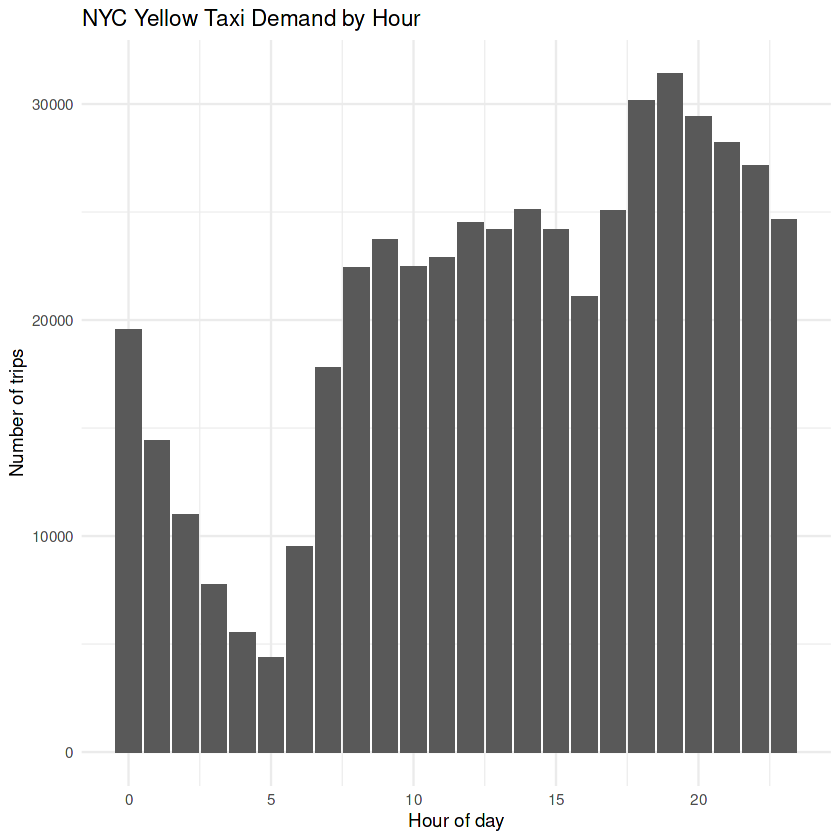

In [41]:
# CELL 30 — Trips by hour

ggplot(
  hourly_demand,
  aes(
    x = hour,
    y = trips
  )
) +
  geom_col() +
  labs(
    title = "NYC Yellow Taxi Demand by Hour",
    x = "Hour of day",
    y = "Number of trips"
  ) +
  theme_minimal()

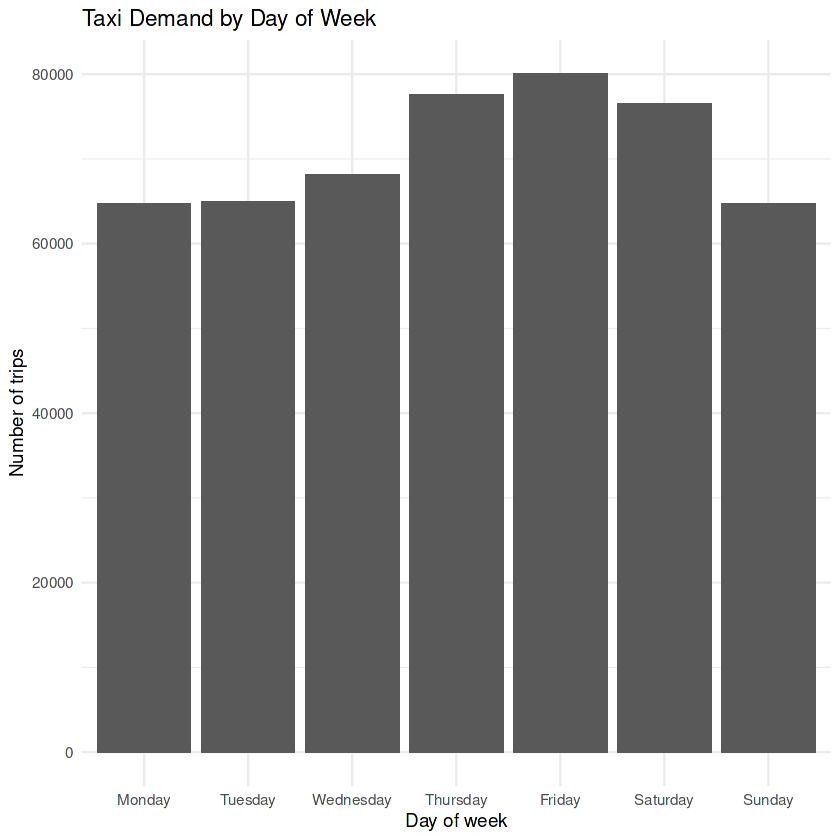

In [42]:
# CELL 31 — Trips by day of week

ggplot(
  weekday_demand,
  aes(
    x = weekday,
    y = trips
  )
) +
  geom_col() +
  labs(
    title = "Taxi Demand by Day of Week",
    x = "Day of week",
    y = "Number of trips"
  ) +
  theme_minimal()

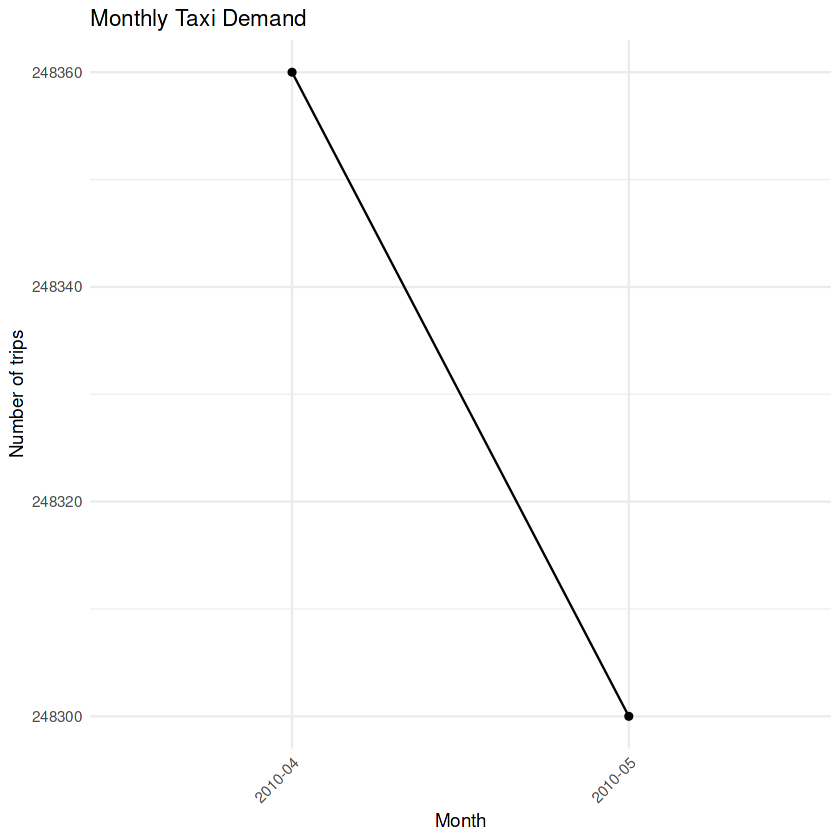

In [43]:
# CELL 32 — Monthly demand

ggplot(
  monthly_demand,
  aes(
    x = year_month,
    y = trips,
    group = 1
  )
) +
  geom_line() +
  geom_point() +
  labs(
    title = "Monthly Taxi Demand",
    x = "Month",
    y = "Number of trips"
  ) +
  theme_minimal() +
  theme(
    axis.text.x = element_text(
      angle = 45,
      hjust = 1
    )
  )

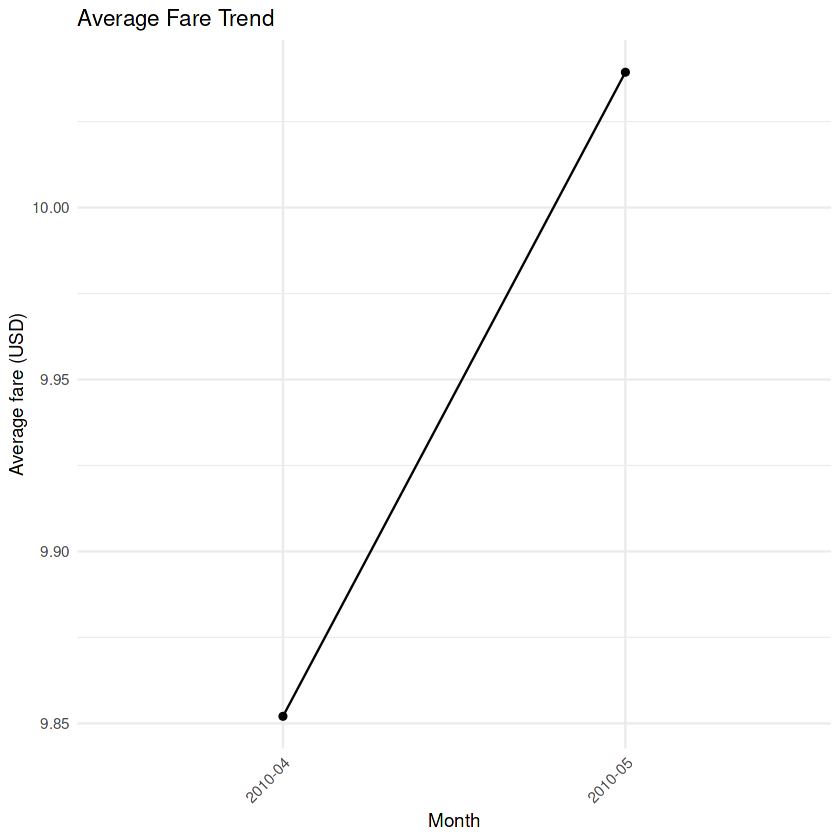

In [44]:
# CELL 33 — Average fare

ggplot(
  monthly_demand,
  aes(
    x = year_month,
    y = average_fare,
    group = 1
  )
) +
  geom_line() +
  geom_point() +
  labs(
    title = "Average Fare Trend",
    x = "Month",
    y = "Average fare (USD)"
  ) +
  theme_minimal() +
  theme(
    axis.text.x = element_text(
      angle = 45,
      hjust = 1
    )
  )

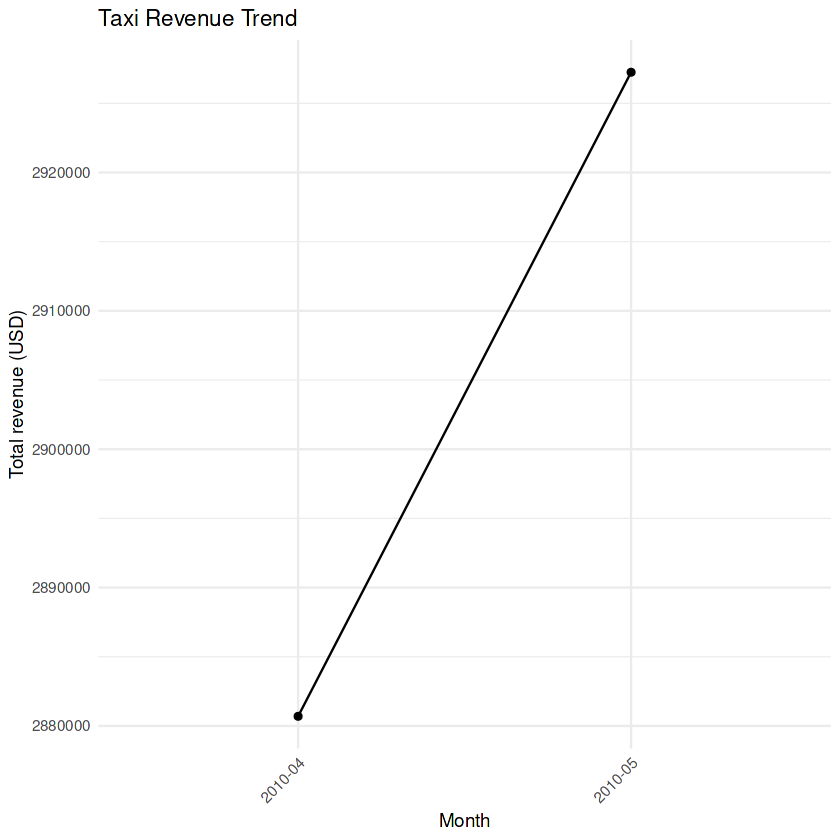

In [45]:
# CELL 34 — Revenue trend

ggplot(
  monthly_demand,
  aes(
    x = year_month,
    y = total_revenue,
    group = 1
  )
) +
  geom_line() +
  geom_point() +
  labs(
    title = "Taxi Revenue Trend",
    x = "Month",
    y = "Total revenue (USD)"
  ) +
  theme_minimal() +
  theme(
    axis.text.x = element_text(
      angle = 45,
      hjust = 1
    )
  )

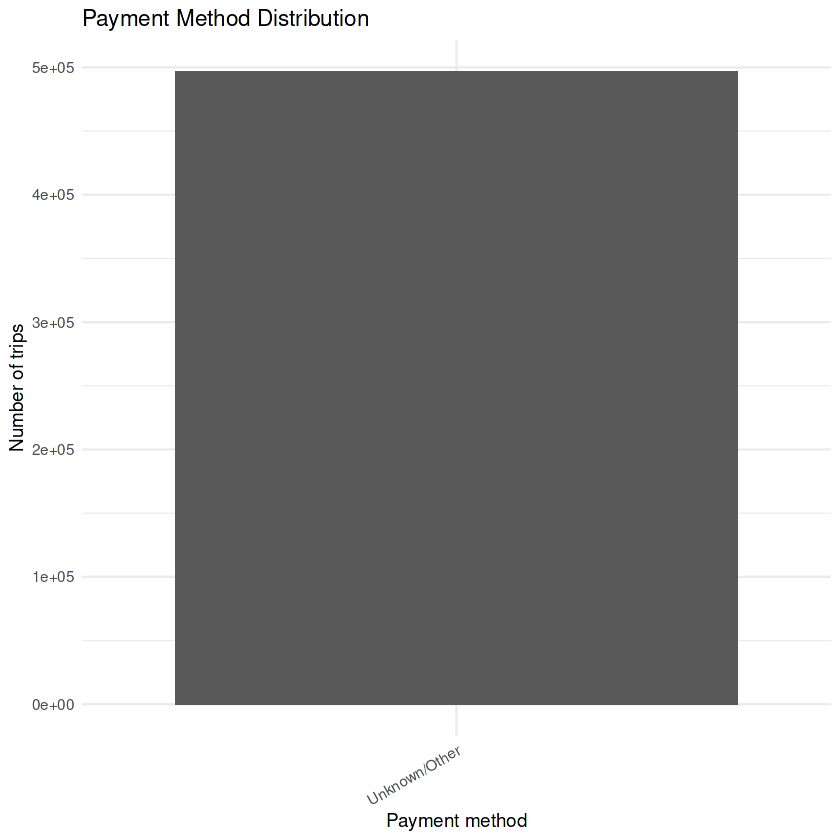

In [46]:
# CELL 35 — Payment-type distribution

ggplot(
  payment_summary,
  aes(
    x = reorder(
      payment_label,
      -trips
    ),
    y = trips
  )
) +
  geom_col() +
  labs(
    title = "Payment Method Distribution",
    x = "Payment method",
    y = "Number of trips"
  ) +
  theme_minimal() +
  theme(
    axis.text.x = element_text(
      angle = 30,
      hjust = 1
    )
  )

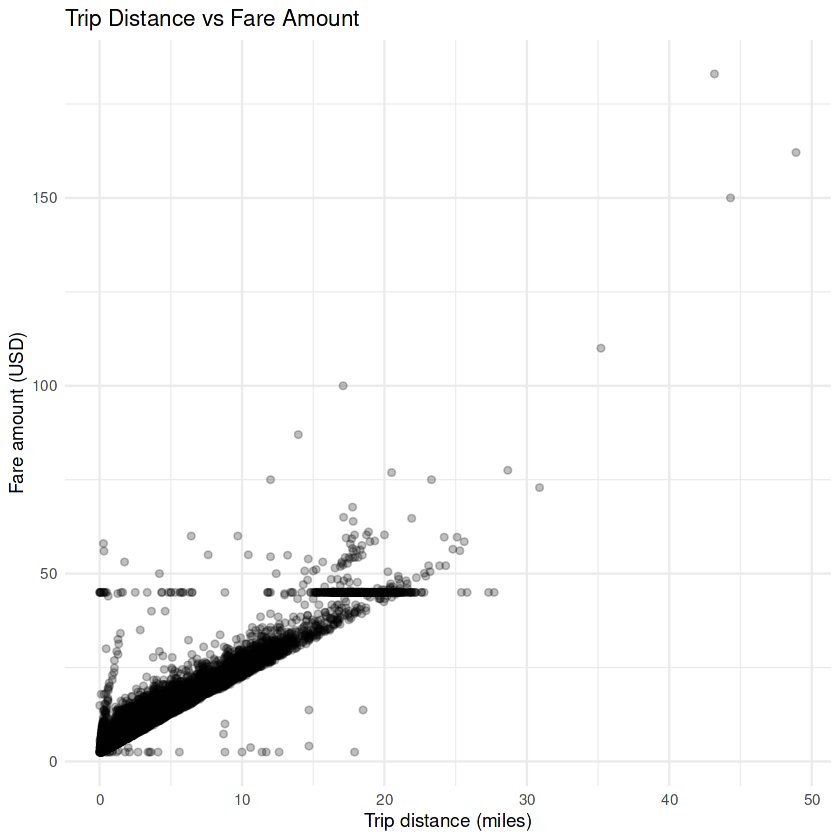

In [47]:
# CELL 36 — Distance vs fare

scatter_data <- head(
  trips_clean[
    ,
    .(
      trip_distance,
      fare_amount
    )
  ],
  min(
    30000L,
    nrow(trips_clean)
  )
)

ggplot(
  scatter_data,
  aes(
    x = trip_distance,
    y = fare_amount
  )
) +
  geom_point(alpha = 0.25) +
  labs(
    title = "Trip Distance vs Fare Amount",
    x = "Trip distance (miles)",
    y = "Fare amount (USD)"
  ) +
  theme_minimal()

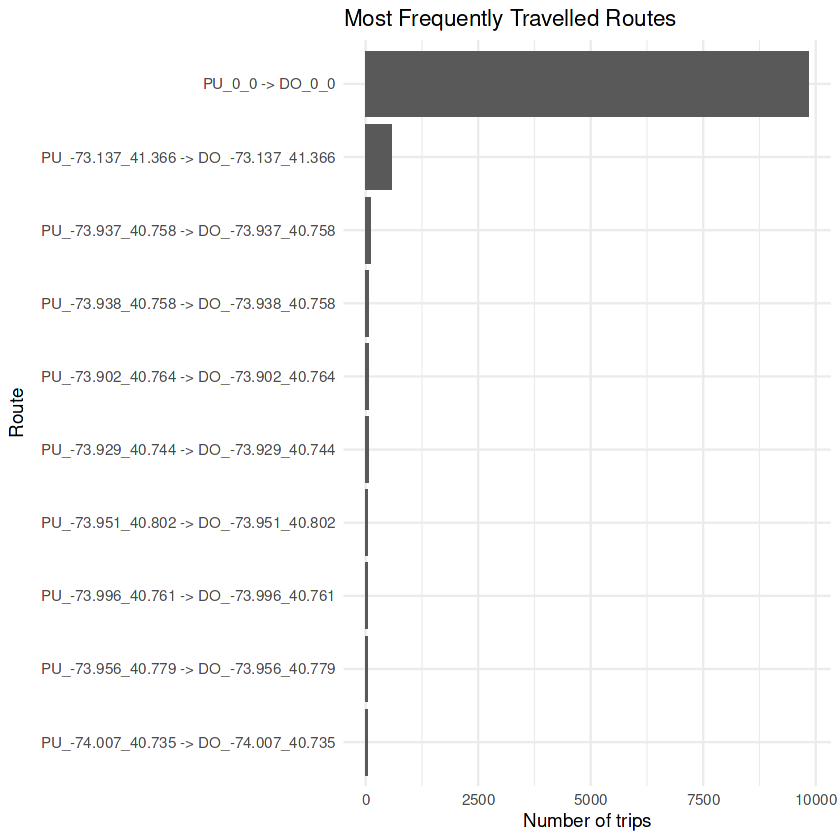

In [48]:
# CELL 37 — Most frequent routes

plot_routes <- head(
  copy(top_routes),
  10L
)

plot_routes[
  ,
  route_label := paste(
    pickup_zone,
    "->",
    dropoff_zone
  )
]

ggplot(
  plot_routes,
  aes(
    x = reorder(
      route_label,
      trips
    ),
    y = trips
  )
) +
  geom_col() +
  coord_flip() +
  labs(
    title = "Most Frequently Travelled Routes",
    x = "Route",
    y = "Number of trips"
  ) +
  theme_minimal()

# 7. Automatically generated observations and recommendation

The following section uses the **actual measurements from this Kaggle run**, so no benchmark or analytical number is fabricated.

In [49]:
# CORRECTED CELL — FINAL CRITICAL ANALYSIS

peak_hour <- hourly_demand[
  which.max(trips)
]

peak_day <- weekday_demand[
  which.max(trips)
]

peak_month <- monthly_demand[
  which.max(trips)
]

top_payment <- payment_summary[
  which.max(trips)
]

top_route <- top_routes[1]
top_revenue_route <- top_revenue_routes[1]

# Fastest system.time approach
fastest_approach <- benchmark_table[1]

# Fastest microbenchmark result
fastest_micro <- micro_summary[1]

# Safely convert the microbenchmark expression to text

micro_expression_text <- paste(
  deparse(
    fastest_micro$expression[[1]]
  ),
  collapse = " "
)

cat(
  "============================================================\n",
  "CRITICAL ANALYSIS\n",
  "============================================================\n\n",
  sep = ""
)

cat(
  "Peak demand hour: ",
  peak_hour$hour,
  " (",
  format(
    peak_hour$trips,
    big.mark = ","
  ),
  " trips).\n\n",
  sep = ""
)

cat(
  "Busiest weekday: ",
  as.character(
    peak_day$weekday
  ),
  " (",
  format(
    peak_day$trips,
    big.mark = ","
  ),
  " trips).\n\n",
  sep = ""
)

cat(
  "Highest-demand month: ",
  peak_month$year_month,
  " (",
  format(
    peak_month$trips,
    big.mark = ","
  ),
  " trips).\n\n",
  sep = ""
)

cat(
  "Most common payment type: ",
  top_payment$payment_label,
  " (",
  format(
    top_payment$trips,
    big.mark = ","
  ),
  " trips).\n\n",
  sep = ""
)

cat(
  "Most frequent route: ",
  top_route$pickup_zone,
  " -> ",
  top_route$dropoff_zone,
  " (",
  format(
    top_route$trips,
    big.mark = ","
  ),
  " trips).\n\n",
  sep = ""
)

cat(
  "Highest-revenue route: ",
  top_revenue_route$pickup_zone,
  " -> ",
  top_revenue_route$dropoff_zone,
  " (USD ",
  format(
    round(
      top_revenue_route$total_revenue,
      2
    ),
    big.mark = ","
  ),
  ").\n\n",
  sep = ""
)

cat(
  "Distance/fare correlation: ",
  round(
    distance_fare_summary$correlation,
    3
  ),
  ".\n\n",
  sep = ""
)

cat(
  "Fastest approach in system.time comparison: ",
  as.character(
    fastest_approach$approach
  ),
  ".\n\n",
  sep = ""
)

cat(
  "Fastest median microbenchmark implementation: ",
  micro_expression_text,
  ".\n\n",
  sep = ""
)

cat(
  "Sequential time: ",
  round(
    sequential_seconds,
    4
  ),
  " seconds\n",
  sep = ""
)

cat(
  "Parallel time: ",
  round(
    parallel_seconds,
    4
  ),
  " seconds\n",
  sep = ""
)

cat(
  "Speedup: ",
  round(
    speedup,
    3
  ),
  "x\n\n",
  sep = ""
)

cat(
  "Recommendation: data.table is recommended as the primary ",
  "framework for large-scale tabular manipulation and aggregation. ",
  "Vectorized operations are appropriate for simple column-wise ",
  "calculations, while functional programming is useful for repeated ",
  "custom operations. Parallel processing should be used when the ",
  "computational workload is large enough to justify parallelization ",
  "overhead.\n",
  sep = ""
)

CRITICAL ANALYSIS

Peak demand hour: 19 (31,393 trips).

Busiest weekday: Friday (80,030 trips).

Highest-demand month: 2010-04 (248,360 trips).

Most common payment type: Unknown/Other (496,660 trips).

Most frequent route: PU_0_0 -> DO_0_0 (9,844 trips).

Highest-revenue route: PU_0_0 -> DO_0_0 (USD 114,170.5).

Distance/fare correlation: 0.951.

Fastest approach in system.time comparison: data.table.

Fastest median microbenchmark implementation: .Primitive("expression").

Sequential time: 0.0776 seconds
Parallel time: 2.1766 seconds
Speedup: 0.036x

Recommendation: data.table is recommended as the primary framework for large-scale tabular manipulation and aggregation. Vectorized operations are appropriate for simple column-wise calculations, while functional programming is useful for repeated custom operations. Parallel processing should be used when the computational workload is large enough to justify parallelization overhead.


# 8. Conclusion

The experiment demonstrates an end-to-end high-performance R workflow for large-scale TLC taxi records.

`data.table` is appropriate for memory-conscious filtering, joins, grouping and aggregation. Vectorized operations are effective for simple calculations, while `lapply()` and `purrr::map()` provide a clear functional abstraction for repeated operations. Parallel processing can reduce runtime for sufficiently expensive independent partitions, but overhead can make it slower for lightweight operations.

The final recommendation is based on the actual benchmark and speedup values produced in this notebook.

In [50]:
# CORRECTED CELL — EXPORT RESULT TABLES

output_dir <- "/kaggle/working"

# Export regular analytical tables

fwrite(
  hourly_demand,
  file.path(
    output_dir,
    "hourly_demand.csv"
  )
)

fwrite(
  weekday_demand,
  file.path(
    output_dir,
    "weekday_demand.csv"
  )
)

fwrite(
  monthly_demand,
  file.path(
    output_dir,
    "monthly_demand.csv"
  )
)

fwrite(
  top_routes,
  file.path(
    output_dir,
    "top_routes.csv"
  )
)

fwrite(
  top_revenue_routes,
  file.path(
    output_dir,
    "top_revenue_routes.csv"
  )
)

fwrite(
  payment_summary,
  file.path(
    output_dir,
    "payment_summary.csv"
  )
)

fwrite(
  benchmark_table,
  file.path(
    output_dir,
    "benchmark_table.csv"
  )
)

micro_summary_export <- copy(
  micro_summary
)

micro_summary_export[
  ,
  expression := vapply(
    expression,
    function(x) {
      paste(
        deparse(x),
        collapse = " "
      )
    },
    character(1)
  )
]

# Verify there are no list columns remaining
list_columns <- names(
  micro_summary_export
)[
  vapply(
    micro_summary_export,
    is.list,
    logical(1)
  )
]

if (length(list_columns) > 0) {
  stop(
    "List columns still remain: ",
    paste(
      list_columns,
      collapse = ", "
    )
  )
}

fwrite(
  micro_summary_export,
  file.path(
    output_dir,
    "microbenchmark_summary.csv"
  )
)

cat(
  "All result tables exported successfully to:\n",
  output_dir,
  "\n"
)

# Show the exported microbenchmark table
print(
  micro_summary_export
)

All result tables exported successfully to:
 /kaggle/working 
                 expression       min_ms    median_ms      mean_ms       max_ms
                     <char>        <num>        <num>        <num>        <num>
1: .Primitive("expression") 2.076683e-06 2.253732e-06 2.352352e-06 2.701079e-06
2: .Primitive("expression") 8.785340e-06 1.079918e-05 1.042957e-05 1.094561e-05
